In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Model 3: PhenoCrop-Presto — Presto Architecture Adapted for pheno_crop_v2

Trains the **Presto encoder architecture from scratch** with modifications for our dataset:

| Presto Original | PhenoCrop-Presto |
|---|---|
| 9 band groups (S1, S2_RGB, RedEdge, NIR, SWIR, ERA5, SRTM, DynWorld, NDVI) | **2 band groups: S1 (3 feats) + S2_Indices (9 feats)** |
| Monthly timestep encoding | **Days-ago encoding (irregular obs)** |
| Lat/lon cartesian token | **Optional (dummy zeros)** |
| Global mean pooling → downstream task | **CLS token → 5-class classifier** |
| Pretrained weights | **Trained from scratch on pheno_crop_v2** |

## Core Presto Ideas We Keep
- **Per-group linear projection** — each sensor group projected independently to `d_model`
- **Channel embedding** — learnable channel-type ID added to each group's tokens
- **Sinusoidal positional encoding** — over time positions
- **Transformer encoder blocks** — multi-head attention + MLP + LayerNorm + residual
- **Masking** — zero-padded timesteps are ignored via key_padding_mask

## Cell 1 — Imports & Config

In [3]:
from pathlib import Path
import math, random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score,
    confusion_matrix, classification_report,
)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

# ── USER CONFIG ──────────────────────────────────────────
DATASET_ROOT   = "/content/drive/MyDrive/pheno_crop_v2"
LOCAL_FALLBACK = Path("./dataset/pheno_crop_v2")
OUTPUT_DIR     = Path("./models")
# ─────────────────────────────────────────────────────────

root = Path(DATASET_ROOT)
if not root.exists() and LOCAL_FALLBACK.exists():
    root = LOCAL_FALLBACK.resolve(); print(f"Using local fallback: {root}")

s1_dir, s2_dir = root / "sentinel_1", root / "sentinel_2"
gt_path = root / "new_ground_truth.csv"
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"gt exists: {gt_path.exists()} | CUDA: {torch.cuda.is_available()}")

gt exists: True | CUDA: True


## Cell 2 — Labels & Plot-Level Split

In [4]:
gt = pd.read_csv(gt_path)
gt["date"] = pd.to_datetime(gt["date"])

stage_names  = sorted(gt["stage_name"].dropna().unique())
stage_to_idx = {n: i for i, n in enumerate(stage_names)}
idx_to_stage = {i: n for n, i in stage_to_idx.items()}
gt["stage_idx"] = gt["stage_name"].map(stage_to_idx)
num_classes  = len(stage_names)
print(f"Classes ({num_classes}): {stage_to_idx}")

plot_df = pd.DataFrame({"plot_id": sorted(gt["plot_id"].unique())})

gss = GroupShuffleSplit(1, test_size=0.15, random_state=SEED)
tv_idx, te_idx = next(gss.split(plot_df, groups=plot_df["plot_id"]))
tv_df = plot_df.iloc[tv_idx].reset_index(drop=True)
test_plots = set(plot_df.iloc[te_idx]["plot_id"])

gss2 = GroupShuffleSplit(1, test_size=0.1765, random_state=SEED)
tr_idx, va_idx = next(gss2.split(tv_df, groups=tv_df["plot_id"]))
train_plots = set(tv_df.iloc[tr_idx]["plot_id"])
val_plots   = set(tv_df.iloc[va_idx]["plot_id"])

assert train_plots.isdisjoint(val_plots) and train_plots.isdisjoint(test_plots)

train_rows = gt[gt["plot_id"].isin(train_plots)]
val_rows   = gt[gt["plot_id"].isin(val_plots)]
test_rows  = gt[gt["plot_id"].isin(test_plots)]
print(f"Plots  train={len(train_plots)} val={len(val_plots)} test={len(test_plots)}")
print(f"Rows   train={len(train_rows)} val={len(val_rows)} test={len(test_rows)}")


Classes (5): {'Bare': 0, 'Growth': 1, 'Ripening': 2, 'Seedling': 3, 'Tillering': 4}
Plots  train=142 val=31 test=31
Rows   train=16330 val=3565 test=3565


## Cell 3 — Dataset

In [5]:
S1_COLS  = ["VV", "VH", "VH_VV_Ratio"]          # 3 radar features
S2_COLS  = ["NDVI", "NDWI", "NDRE", "EVI",
             "SAVI", "MSAVI", "NDMI", "GNDVI"]   # 8 optical features

LOOKBACK = 90
MAX_T    = 30


# ── Dataset ──────────────────────────────────────────────
class PhenoCropDataset(Dataset):
    def __init__(self, gt_df, s1_dir, s2_dir):
        self.gt = gt_df.sort_values(["plot_id", "date"]).reset_index(drop=True)
        self.s1_cache, self.s2_cache = {}, {}
        for pid in sorted(self.gt["plot_id"].unique()):
            p1 = Path(s1_dir) / f"plot_{pid}_sar.csv"
            p2 = Path(s2_dir) / f"plot_{pid}_indices.csv"
            if p1.exists():
                d = pd.read_csv(p1); d["date"] = pd.to_datetime(d["date"])
                self.s1_cache[pid] = d
            if p2.exists():
                d = pd.read_csv(p2); d["date"] = pd.to_datetime(d["date"])
                self.s2_cache[pid] = d

    def __len__(self): return len(self.gt)

    def _window(self, df, target_date, cols):
        feats    = np.zeros((MAX_T, len(cols)), dtype=np.float32)
        days_arr = np.zeros(MAX_T,              dtype=np.int64)
        valid    = np.zeros(MAX_T,              dtype=bool)
        if df is None or df.empty:
            return feats, days_arr, valid
        for c in cols:
            if c not in df.columns: df[c] = 0.0
        start = target_date - pd.Timedelta(days=LOOKBACK)
        win = df[(df["date"] > start) & (df["date"] <= target_date)].sort_values("date")
        if win.empty:
            return feats, days_arr, valid
        n = min(len(win), MAX_T)
        feats[-n:]    = win[cols].fillna(0.0).to_numpy(dtype=np.float32)[-n:]
        d_ago = (target_date - win["date"]).dt.days.to_numpy(dtype=np.int64)
        days_arr[-n:] = d_ago[-n:]
        valid[-n:]    = True
        return feats, days_arr, valid

    def __getitem__(self, idx):
        row   = self.gt.iloc[idx]
        pid   = int(row["plot_id"])
        tdate = row["date"]
        label = int(row["stage_idx"])

        s1f, s1d, s1v = self._window(self.s1_cache.get(pid), tdate, S1_COLS)
        s2f, s2d, s2v = self._window(self.s2_cache.get(pid), tdate, S2_COLS)

        days_ago = np.where(s2v, s2d, s1d)

        return {
            "s1":      torch.tensor(s1f),
            "s2":      torch.tensor(s2f),
            "days":    torch.tensor(days_ago).long(),
            "s1_mask": torch.tensor(~s1v),
            "s2_mask": torch.tensor(~s2v),
            "label":   torch.tensor(label).long(),
        }


train_ds = PhenoCropDataset(train_rows, s1_dir, s2_dir)
val_ds   = PhenoCropDataset(val_rows,   s1_dir, s2_dir)
test_ds  = PhenoCropDataset(test_rows,  s1_dir, s2_dir)
print(f"Datasets: {len(train_ds)} / {len(val_ds)} / {len(test_ds)}")

s = train_ds[0]
for k, v in s.items():
    if hasattr(v, 'shape'): print(f"  {k}: {tuple(v.shape)} {v.dtype}")

Datasets: 16330 / 3565 / 3565
  s1: (30, 3) torch.float32
  s2: (30, 8) torch.float32
  days: (30,) torch.int64
  s1_mask: (30,) torch.bool
  s2_mask: (30,) torch.bool
  label: () torch.int64


## Cell 4 — PhenoCrop-Presto Architecture

```
Input
 ├─ S1 [B,T,3]  ──► Linear(3→d)  ─┐
 │                                  ├──► + channel_embed + pos_embed + days_embed
 └─ S2 [B,T,8]  ──► Linear(8→d)  ─┘           │
                                             concat
                                          [B, 2T, d]
                                               │
                                    Transformer Encoder (L layers)
                                        (with key_padding_mask)
                                               │
                                         mean-pool valid
                                           [B, d]
                                               │
                                      Classifier Head
                                           [B, 5]
```

In [6]:
def sinusoid_table(n_pos: int, d_hid: int) -> torch.Tensor:
    pos = torch.arange(n_pos).float().unsqueeze(1)
    dim = torch.arange(d_hid).float().unsqueeze(0)
    angles = pos / torch.pow(10000, 2 * (dim // 2) / d_hid)
    angles[:, 0::2] = torch.sin(angles[:, 0::2])
    angles[:, 1::2] = torch.cos(angles[:, 1::2])
    return angles


def month_table(d_hid: int) -> torch.Tensor:
    assert d_hid % 2 == 0
    angles = torch.arange(12).float() / 12 * 2 * math.pi
    sin_t  = torch.sin(angles).unsqueeze(1).expand(-1, d_hid // 2)
    cos_t  = torch.cos(angles).unsqueeze(1).expand(-1, d_hid // 2)
    return torch.cat([sin_t, cos_t], dim=-1)


# ── Transformer Block ────────────────────────────────────
class TransformerBlock(nn.Module):
    def __init__(self, d: int, n_heads: int, mlp_ratio: float = 2.0, drop: float = 0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(d)
        self.attn  = nn.MultiheadAttention(d, n_heads, dropout=drop, batch_first=True)
        self.norm2 = nn.LayerNorm(d)
        self.mlp   = nn.Sequential(
            nn.Linear(d, int(d * mlp_ratio)), nn.GELU(), nn.Dropout(drop),
            nn.Linear(int(d * mlp_ratio), d), nn.Dropout(drop),
        )

    def forward(self, x, key_padding_mask=None):
        h = self.norm1(x)
        h, _ = self.attn(h, h, h, key_padding_mask=key_padding_mask, need_weights=False)
        x = x + h
        x = x + self.mlp(self.norm2(x))
        return x


# ── PhenoCropPresto Encoder ──────────────────────────────
class PhenoCropPresto(nn.Module):
    BAND_GROUPS = {"S1": len(S1_COLS), "S2": len(S2_COLS)}  # {3, 8}
    N_GROUPS    = len(BAND_GROUPS)
    MAX_DAYS    = 120

    def __init__(
        self,
        d_model:     int   = 128,
        depth:       int   = 4,
        n_heads:     int   = 8,
        mlp_ratio:   float = 2.0,
        drop:        float = 0.1,
        num_classes: int   = 5,
    ):
        super().__init__()
        assert d_model % 4 == 0
        self.d_model = d_model
        self.d_pos   = d_model // 2
        self.d_ch    = d_model // 4
        self.d_month = d_model // 4

        self.group_proj = nn.ModuleDict({
            name: nn.Linear(n_feats, d_model)
            for name, n_feats in self.BAND_GROUPS.items()
        })
        self.channel_embed = nn.Embedding(self.N_GROUPS, self.d_ch)

        pos_tab   = sinusoid_table(self.MAX_DAYS + 1, self.d_pos)
        month_tab = month_table(self.d_month)
        self.register_buffer("pos_tab",   pos_tab)
        self.register_buffer("month_tab", month_tab)

        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, n_heads, mlp_ratio, drop)
            for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(d_model)

        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(drop),
            nn.Linear(d_model // 2, num_classes),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, std=0.02)

    def _pos_embed(self, days_ago):
        idx = days_ago.clamp(0, self.MAX_DAYS)
        return self.pos_tab[idx]

    def _month_embed(self, days_ago, ref_date_month: int = 1):
        months_ago = (days_ago // 30).clamp(0, 11)
        month_idx  = (ref_date_month - months_ago) % 12
        return self.month_tab[month_idx]

    def forward(self, s1, s2, days, s1_mask, s2_mask):
        B, T, _ = s1.shape
        device   = s1.device

        pos_enc   = self._pos_embed(days)
        month_enc = self._month_embed(days)

        tokens_list, mask_list = [], []

        for g_idx, (group_name, feat_tensor, group_mask) in enumerate([
            ("S1", s1, s1_mask),
            ("S2", s2, s2_mask),
        ]):
            tok = self.group_proj[group_name](feat_tensor)
            ch_idx = torch.tensor(g_idx, device=device)
            ch_enc = self.channel_embed(ch_idx)
            ch_enc = ch_enc.unsqueeze(0).unsqueeze(0).expand(B, T, -1)
            full_pos = torch.cat([pos_enc, ch_enc, month_enc], dim=-1)
            tok = tok + full_pos
            tokens_list.append(tok)
            mask_list.append(group_mask)

        x   = torch.cat(tokens_list, dim=1)
        kpm = torch.cat(mask_list, dim=1)

        all_masked = kpm.all(dim=1)
        if all_masked.any():
            kpm = kpm.clone()
            kpm[all_masked, -1] = False

        for blk in self.blocks:
            x = blk(x, key_padding_mask=kpm)
        x = self.norm(x)

        valid  = (~kpm).unsqueeze(-1).float()
        pooled = (x * valid).sum(dim=1) / valid.sum(dim=1).clamp(min=1)

        return self.classifier(pooled)


# ── Sanity check ─────────────────────────────────────────
model = PhenoCropPresto(d_model=128, depth=4, n_heads=8, num_classes=num_classes)
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params:     {total:,}")
print(f"Trainable params: {trainable:,}")

dummy_s1  = torch.randn(4, MAX_T, len(S1_COLS))
dummy_s2  = torch.randn(4, MAX_T, len(S2_COLS))
dummy_d   = torch.randint(0, 90, (4, MAX_T))
dummy_m1  = torch.zeros(4, MAX_T, dtype=torch.bool)
dummy_m2  = torch.zeros(4, MAX_T, dtype=torch.bool)
out = model(dummy_s1, dummy_s2, dummy_d, dummy_m1, dummy_m2)
print(f"Output shape: {out.shape}  ✓")

Total params:     540,485
Trainable params: 540,485
Output shape: torch.Size([4, 5])  ✓


## Cell 5 — DataLoaders & Class Weights

In [7]:
BATCH_SIZE = 64

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
print(f"Batches: {len(train_loader)} / {len(val_loader)} / {len(test_loader)}")


def class_weights(ds, nc):
    labels = [ds[i]["label"].item() for i in range(len(ds))]
    counts = torch.bincount(torch.tensor(labels), minlength=nc)
    counts = counts.clamp(min=1).float()
    w = len(labels) / (nc * counts)
    return w.clamp(max=10.0)


cw = class_weights(train_ds, num_classes)
print(f"Class weights: {dict(enumerate(cw.numpy().round(3)))}")

Batches: 256 / 56 / 56
Class weights: {0: np.float32(1.958), 1: np.float32(0.907), 2: np.float32(1.316), 3: np.float32(0.961), 4: np.float32(0.63)}


## Cell 6 — Training & Evaluation Functions

In [8]:
def run_epoch(model, loader, criterion, optimizer, device):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = 0.0
    all_true, all_pred = [], []

    with torch.set_grad_enabled(is_train):
        for batch in loader:
            s1      = batch["s1"].to(device)
            s2      = batch["s2"].to(device)
            days    = batch["days"].to(device)
            s1_mask = batch["s1_mask"].to(device)
            s2_mask = batch["s2_mask"].to(device)
            labels  = batch["label"].to(device)

            logits = model(s1, s2, days, s1_mask, s2_mask)
            loss   = criterion(logits, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            total_loss += loss.item() * labels.size(0)
            preds = logits.argmax(dim=1)
            all_true.extend(labels.cpu().numpy())
            all_pred.extend(preds.detach().cpu().numpy())

    n        = max(len(all_true), 1)
    acc      = accuracy_score(all_true, all_pred)
    macro_f1 = f1_score(all_true, all_pred, average="macro", zero_division=0)
    return total_loss / n, acc, macro_f1, all_true, all_pred


def train(model, train_loader, val_loader, cw,
          epochs=100, lr=1e-3, patience=15):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}")
    model  = model.to(device)

    criterion = nn.CrossEntropyLoss(weight=cw.to(device))
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=5
    )

    best_f1, wait, best_state = -1.0, 0, None

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc, tr_f1, _, _ = run_epoch(model, train_loader, criterion, optimizer, device)
        va_loss, va_acc, va_f1, _, _ = run_epoch(model, val_loader,   criterion, None,      device)
        scheduler.step(va_f1)

        if va_f1 > best_f1:
            best_f1, wait = va_f1, 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            wait += 1

        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss {tr_loss:.4f} Acc {tr_acc*100:.2f}% F1 {tr_f1:.4f} | "
            f"Val Loss {va_loss:.4f} Acc {va_acc*100:.2f}% F1 {va_f1:.4f}"
        )

        if wait >= patience:
            print(f"Early stopping at epoch {epoch}. Best val F1: {best_f1:.4f}")
            break

    if best_state:
        model.load_state_dict(best_state)
    return model, device



## Cell 7 — Train

In [9]:
model = PhenoCropPresto(
    d_model     = 128,
    depth       = 4,
    n_heads     = 8,
    mlp_ratio   = 2.0,
    drop        = 0.1,
    num_classes = num_classes,
)

trained_model, device = train(
    model, train_loader, val_loader, cw,
    epochs=100, lr=1e-3, patience=15,
)


Device: cuda
Epoch 001 | Train Loss 0.8975 Acc 57.56% F1 0.5602 | Val Loss 0.8078 Acc 65.67% F1 0.6526
Epoch 002 | Train Loss 0.7585 Acc 63.67% F1 0.6242 | Val Loss 0.8450 Acc 63.17% F1 0.6225
Epoch 003 | Train Loss 0.7174 Acc 65.57% F1 0.6422 | Val Loss 0.7607 Acc 66.96% F1 0.6641
Epoch 004 | Train Loss 0.6816 Acc 66.94% F1 0.6576 | Val Loss 0.7453 Acc 66.17% F1 0.6562
Epoch 005 | Train Loss 0.6677 Acc 67.79% F1 0.6661 | Val Loss 0.8708 Acc 57.67% F1 0.5675
Epoch 006 | Train Loss 0.6513 Acc 68.67% F1 0.6747 | Val Loss 0.6898 Acc 67.35% F1 0.6659
Epoch 007 | Train Loss 0.6333 Acc 69.36% F1 0.6815 | Val Loss 0.6953 Acc 71.56% F1 0.7090
Epoch 008 | Train Loss 0.6202 Acc 69.82% F1 0.6871 | Val Loss 0.6323 Acc 71.81% F1 0.7173
Epoch 009 | Train Loss 0.6081 Acc 70.23% F1 0.6896 | Val Loss 0.7257 Acc 68.02% F1 0.6749
Epoch 010 | Train Loss 0.6003 Acc 71.02% F1 0.6985 | Val Loss 0.6912 Acc 70.38% F1 0.6966
Epoch 011 | Train Loss 0.5913 Acc 70.99% F1 0.6975 | Val Loss 0.7123 Acc 71.42% F1 0.70

## Cell 8 — Evaluate


[Validation] Loss: 0.6327 | Acc: 73.74% | Macro-F1: 0.7393
  [0] Bare: recall=0.7583
  [1] Growth: recall=0.7247
  [2] Ripening: recall=0.7907
  [3] Seedling: recall=0.7441
  [4] Tillering: recall=0.6904
              precision    recall  f1-score   support

        Bare       0.71      0.76      0.74       360
      Growth       0.70      0.72      0.71       781
    Ripening       0.63      0.79      0.70       774
    Seedling       0.85      0.74      0.79       723
   Tillering       0.82      0.69      0.75       927

    accuracy                           0.74      3565
   macro avg       0.74      0.74      0.74      3565
weighted avg       0.75      0.74      0.74      3565



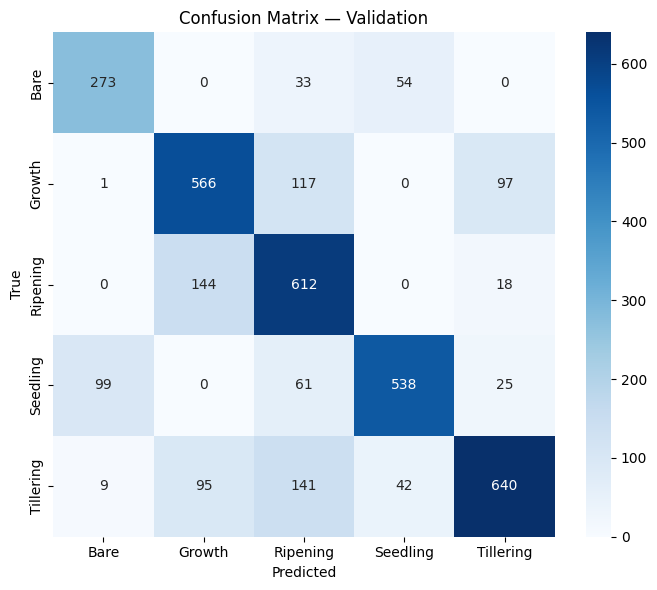


[Test (Unseen Plots)] Loss: 0.5848 | Acc: 73.04% | Macro-F1: 0.7251
  [0] Bare: recall=0.7199
  [1] Growth: recall=0.7265
  [2] Ripening: recall=0.9625
  [3] Seedling: recall=0.6900
  [4] Tillering: recall=0.6805
              precision    recall  f1-score   support

        Bare       0.74      0.72      0.73       332
      Growth       0.86      0.73      0.79       786
    Ripening       0.42      0.96      0.58       427
    Seedling       0.77      0.69      0.73       887
   Tillering       0.97      0.68      0.80      1133

    accuracy                           0.73      3565
   macro avg       0.75      0.76      0.73      3565
weighted avg       0.81      0.73      0.75      3565



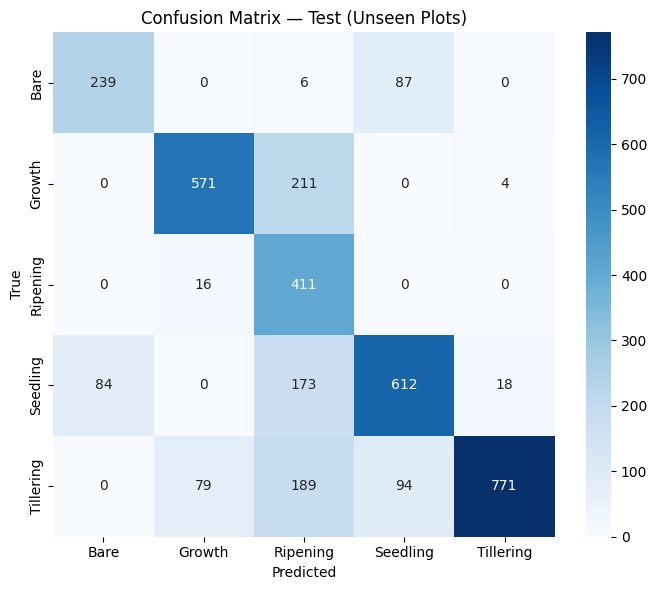


  model_2_v2 (BiGRU+Transformer) Test F1 : 0.6929
  PhenoCrop-Presto               Test F1 : 0.7251
  Delta                                  : +0.0322


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns


def evaluate(model, loader, split, device, num_classes, idx_to_stage):
    criterion = nn.CrossEntropyLoss()
    loss, acc, f1, y_true, y_pred = run_epoch(model, loader, criterion, None, device)
    labels = list(range(num_classes))
    names  = [idx_to_stage[i] for i in labels]

    print(f"\n[{split}] Loss: {loss:.4f} | Acc: {acc*100:.2f}% | Macro-F1: {f1:.4f}")
    recalls = recall_score(y_true, y_pred, average=None, labels=labels, zero_division=0)
    for i, n, r in zip(labels, names, recalls):
        print(f"  [{i}] {n}: recall={r:.4f}")
    print(classification_report(y_true, y_pred, labels=labels, target_names=names, zero_division=0))

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    _, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=names, yticklabels=names, ax=ax)
    ax.set_title(f"Confusion Matrix — {split}")
    ax.set_ylabel("True"); ax.set_xlabel("Predicted")
    plt.tight_layout(); plt.show()
    return loss, acc, f1


val_loss,  val_acc,  val_f1  = evaluate(trained_model, val_loader,  "Validation",         device, num_classes, idx_to_stage)
test_loss, test_acc, test_f1 = evaluate(trained_model, test_loader, "Test (Unseen Plots)", device, num_classes, idx_to_stage)

print("\n" + "="*55)
print(f"  model_2_v2 (BiGRU+Transformer) Test F1 : 0.6929")
print(f"  PhenoCrop-Presto               Test F1 : {test_f1:.4f}")
print(f"  Delta                                  : {test_f1 - 0.6929:+.4f}")
print("="*55)



## Cell 9 — Save Model & Predictions

In [11]:
save_path = OUTPUT_DIR / "phenocrop_presto_8feat.pth"
torch.save({
    "model_state_dict": trained_model.state_dict(),
    "stage_to_idx":     stage_to_idx,
    "idx_to_stage":     idx_to_stage,
    "num_classes":      num_classes,
    "s1_cols":          S1_COLS,
    "s2_cols":          S2_COLS,
    "val_macro_f1":     val_f1,
    "test_macro_f1":    test_f1,
    "hparams":          {"d_model": 128, "depth": 4, "n_heads": 8},
}, save_path)
print(f"Model saved: {save_path}")

trained_model.eval()
rows = []
with torch.no_grad():
    for batch in test_loader:
        logits = trained_model(
            batch["s1"].to(device), batch["s2"].to(device),
            batch["days"].to(device),
            batch["s1_mask"].to(device), batch["s2_mask"].to(device),
        )
        probs  = torch.softmax(logits, dim=1).cpu().numpy()
        preds  = logits.argmax(dim=1).cpu().numpy()
        truths = batch["label"].numpy()
        for i in range(len(preds)):
            row = {
                "true_stage": idx_to_stage[truths[i]],
                "pred_stage": idx_to_stage[preds[i]],
            }
            for c, n in idx_to_stage.items():
                row[f"prob_{n}"] = float(probs[i, c])
            rows.append(row)

pred_df   = pd.DataFrame(rows)
pred_path = OUTPUT_DIR / "pred_phenocrop_presto_8feat.csv"
pred_df.to_csv(pred_path, index=False)
print(f"Predictions saved: {pred_path}")
pred_df.head()

Model saved: models/phenocrop_presto_8feat.pth
Predictions saved: models/pred_phenocrop_presto_8feat.csv


,true_stage,pred_stage,prob_Bare,prob_Growth,prob_Ripening,prob_Seedling,prob_Tillering
0,Bare,Bare,0.989981,1.198404e-05,1.954245e-05,0.009660,0.000328
1,Bare,Bare,0.989591,2.317315e-06,1.017701e-06,0.010318,0.000088
2,Bare,Bare,0.990569,1.125527e-06,4.061659e-07,0.009389,0.000040
3,Bare,Bare,0.990757,4.792469e-07,1.585025e-07,0.009223,0.000019
4,Bare,Bare,0.981580,2.350102e-06,7.976649e-07,0.018406,0.000011


---
## Architecture Summary

```
PhenoCropPresto
  │
  ├─ S1 group: Linear(3 → 128)  ─────┐
  │   + pos(days_ago)[0:64]           │
  │   + channel_embed[S1][64:96]      ├──► concat → [B, 2T, 128]
  │   + month_enc[96:128]             │
  │                                   │
  └─ S2 group: Linear(8 → 128)  ─────┘
      + pos(days_ago)[0:64]
      + channel_embed[S2][64:96]
      + month_enc[96:128]
  │
  ├─ TransformerBlock ×4  (MHA + MLP + LayerNorm + residual)
  │   key_padding_mask = missing S1/S2 timesteps
  │
  ├─ LayerNorm → masked mean-pool → [B, 128]
  │
  └─ Classifier: Linear(128→64) → GELU → Dropout → Linear(64→5)
```

**Hyperparameter tuning guide:**

| Param | Default | Try |
|---|---|---|
| `d_model` | 128 | 64, 256 |
| `depth` | 4 | 2, 6 |
| `n_heads` | 8 | 4, 16 |
| `LOOKBACK` | 90 | 60, 120 |
| `MAX_T` | 30 | 20, 48 |